In [3]:
# Import the libraries you'll need
import pandas as pd   
import numpy as np  
import matplotlib.pyplot as plt    
import seaborn as sns  

# Make plots look nicer 
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [4]:
# Load the dataset
df = pd.read_csv('../Data/fake_job_postings.csv')

print("shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

shape: (17880, 18)
Columns: ['job_id', 'title', 'location', 'department', 'salary_range', 'company_profile', 'description', 'requirements', 'benefits', 'telecommuting', 'has_company_logo', 'has_questions', 'employment_type', 'required_experience', 'required_education', 'industry', 'function', 'fraudulent']


,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [5]:
#Get infor about data types and missing values
df.info()

#Statistical summary of numeric columns
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   title                17880 non-null  object
 2   location             17534 non-null  object
 3   department           6333 non-null   object
 4   salary_range         2868 non-null   object
 5   company_profile      14572 non-null  object
 6   description          17879 non-null  object
 7   requirements         15184 non-null  object
 8   benefits             10668 non-null  object
 9   telecommuting        17880 non-null  int64 
 10  has_company_logo     17880 non-null  int64 
 11  has_questions        17880 non-null  int64 
 12  employment_type      14409 non-null  object
 13  required_experience  10830 non-null  object
 14  required_education   9775 non-null   object
 15  industry             12977 non-null  object
 16  func

,job_id,telecommuting,has_company_logo,has_questions,fraudulent
count,17880.000000,17880.000000,17880.000000,17880.000000,17880.000000
mean,8940.500000,0.042897,0.795302,0.491723,0.048434
std,5161.655742,0.202631,0.403492,0.499945,0.214688
min,1.000000,0.000000,0.000000,0.000000,0.000000
25%,4470.750000,0.000000,1.000000,0.000000,0.000000
50%,8940.500000,0.000000,1.000000,0.000000,0.000000
75%,13410.250000,0.000000,1.000000,1.000000,0.000000
max,17880.000000,1.000000,1.000000,1.000000,1.000000


fraudulent
0    17014
1      866
Name: count, dtype: int64
fraudulent
0    95.1566
1     4.8434
Name: proportion, dtype: float64


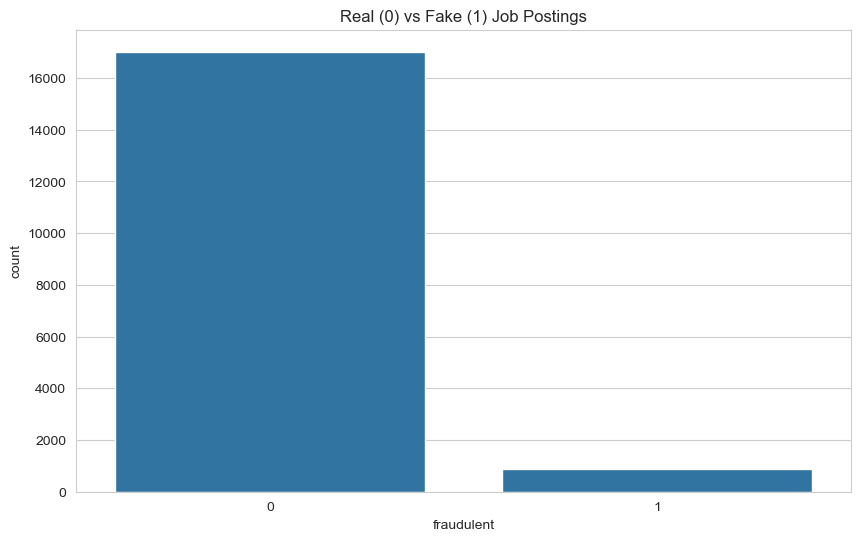

In [6]:
#Count real vs fake
print(df['fraudulent'].value_counts())
print(df['fraudulent'].value_counts(normalize=True) * 100)

#visualize it
sns.countplot(x='fraudulent', data=df)
plt.title('Real (0) vs Fake (1) Job Postings')
plt.show()

In [7]:
# Count and percentage of missing values per column
missing = df.isnull().sum()
missing_percentage = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing': missing, 'Percent': missing_percentage})
print(missing_df.sort_values('Percent', ascending=False))

                     Missing    Percent
salary_range           15012  83.959732
department             11547  64.580537
required_education      8105  45.329978
benefits                7212  40.335570
required_experience     7050  39.429530
function                6455  36.101790
industry                4903  27.421700
employment_type         3471  19.412752
company_profile         3308  18.501119
requirements            2696  15.078300
location                 346   1.935123
description                1   0.005593
title                      0   0.000000
job_id                     0   0.000000
telecommuting              0   0.000000
has_questions              0   0.000000
has_company_logo           0   0.000000
fraudulent                 0   0.000000


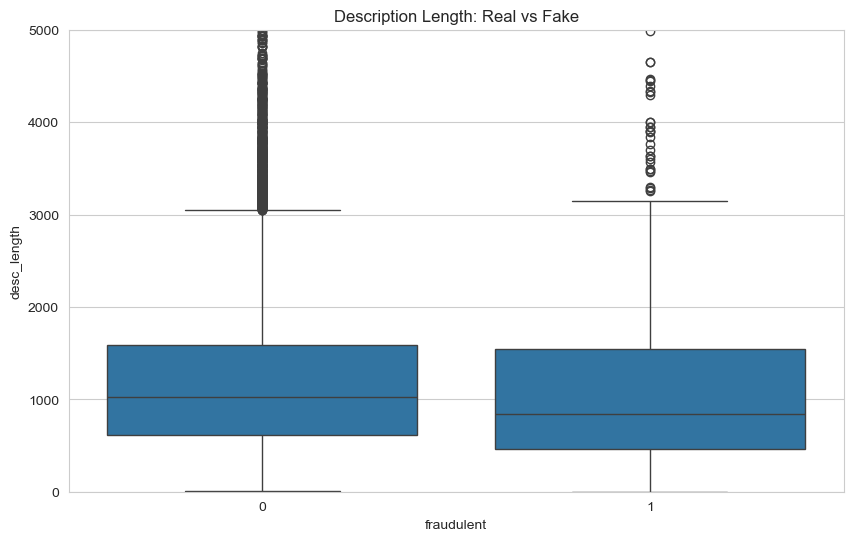

fraudulent
0    1221.219701
1    1154.834873
Name: desc_length, dtype: float64


In [8]:
#Add a column for description length
df['desc_length'] = df['description'].fillna('').apply(len)

#Compare description lengths between real and fake
sns.boxplot(x='fraudulent', y='desc_length', data=df)
plt.title('Description Length: Real vs Fake')
plt.ylim(0, 5000)  #Limit y-axis to see the bulk of data
plt.show()

# Print averages
print(df.groupby('fraudulent')['desc_length'].mean())

In [9]:
# Top countries for fake postings
df['country'] = df['location'].fillna('').apply(lambda x: x.split(',')[0])
fake_countries = df[df['fraudulent']==1]['country'].value_counts().head(10)
print("Top 10 countries with fake postings:")
print(fake_countries)

#Employment type breakdown
pd.crosstab(df['employment_type'], df['fraudulent'], normalize='index') * 100


Top 10 countries with fake postings:
country
US    730
AU     40
GB     23
       19
MY     12
CA     12
QA      6
BH      5
IN      4
PL      3
Name: count, dtype: int64


fraudulent,0,1
employment_type,,
Contract,97.112861,2.887139
Full-time,95.783133,4.216867
Other,93.392070,6.607930
Part-time,90.715182,9.284818
Temporary,99.170124,0.829876


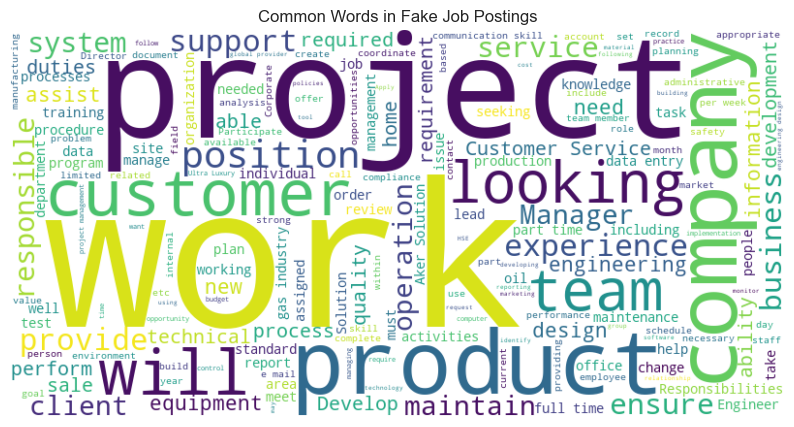

In [12]:
from wordcloud import WordCloud

#Combine all fake descriptiions
fake_text = ' '.join(df[df['fraudulent']==1]['description'].fillna('').astype(str))

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(fake_text)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Common Words in Fake Job Postings')
plt.show()